In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

N_TRAIN = 10000
N_TEST  = 2000

idx_train = np.random.choice(len(x_train), N_TRAIN, replace=False)
idx_test = np.random.choice(len(x_test), N_TEST, replace=False)

x_train = x_train[idx_train]
x_test = x_test[idx_test]

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (10000, 28, 28, 1)
Test shape: (2000, 28, 28, 1)


In [3]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

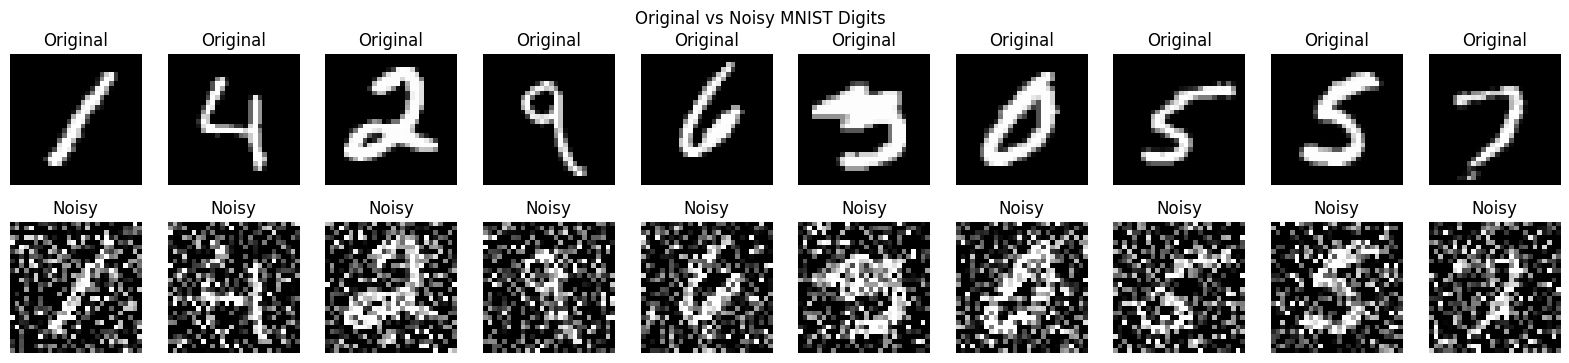

In [4]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):

    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")
plt.suptitle("Original vs Noisy MNIST Digits")
plt.show()

In [5]:
input_img = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D((2, 2), padding="same")(x)

x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_denoising_autoencoder.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.4525
Epoch 1: val_loss improved from None to 0.17424, saving model to best_denoising_autoencoder.h5



Epoch 1: finished saving model to best_denoising_autoencoder.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.3255 - val_loss: 0.1742
Epoch 2/50
75/79 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1635
Epoch 2: val_loss improved from 0.17424 to 0.14218, saving model to best_denoising_autoencoder.h5



Epoch 2: finished saving model to best_denoising_autoencoder.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1543 - val_loss: 0.1422
Epoch 3/50
75/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1388
Epoch 3: val_loss improved from 0.14218 to 0.13387, saving model to best_denoising_autoencoder.h5



Epoch 3: finished saving model to best_denoising_autoencoder.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1356 - val_loss: 0.1339
Epoch 4/50
69/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1299
Epoch 4: val_loss improved from 0.13387 to 0.12292, saving model to best_denoising_autoencoder.h5



Epoch 4: finished saving model to best_denoising_autoencoder.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1279 - val_loss: 0.1229
Epoch 5/50
70/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1242
Epoch 5: val_loss improved from 0.12292 to 0.11990, saving model to best_denoising_autoencoder.h5


...


Epoch 41: finished saving model to best_denoising_autoencoder.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1005 - val_loss: 0.1005
Epoch 42/50
77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1000
Epoch 42: val_loss improved from 0.10054 to 0.10034, saving model to best_denoising_autoencoder.h5



Epoch 42: finished saving model to best_denoising_autoencoder.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1003 - val_loss: 0.1003
Epoch 43/50
70/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1004
Epoch 43: val_loss did not improve from 0.10034
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1000 - val_loss: 0.1012
Epoch 44/50
70/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1001
Epoch 44: val_loss did not improve from 0.10034
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1002 - val_loss: 0.1004
Epoch 45/50
70/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0997
Epoch 45: val_loss improved from 0.10034 to 0.09997, saving model to best_denoising_autoencoder.h5



Epoch 45: finished saving model to best_denoising_autoencoder.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0998 - val_loss: 0.1000
Epoch 46/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0996
Epoch 46: val_loss did not improve from 0.09997
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0997 - val_loss: 0.1011
Epoch 47/50
70/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0997
Epoch 47: val_loss did not improve from 0.09997
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0996 - val_loss: 0.1014
Epoch 48/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0997
Epoch 48: val_loss improved from 0.09997 to 0.09976, saving model to best_denoising_autoencoder.h5



Epoch 48: finished saving model to best_denoising_autoencoder.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0995 - val_loss: 0.0998
Epoch 49/50
70/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0994
Epoch 49: val_loss did not improve from 0.09976
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0994 - val_loss: 0.0999
Epoch 50/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0993
Epoch 50: val_loss improved from 0.09976 to 0.09963, saving model to best_denoising_autoencoder.h5



Epoch 50: finished saving model to best_denoising_autoencoder.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0992 - val_loss: 0.0996
Restoring model weights from the end of the best epoch: 50.


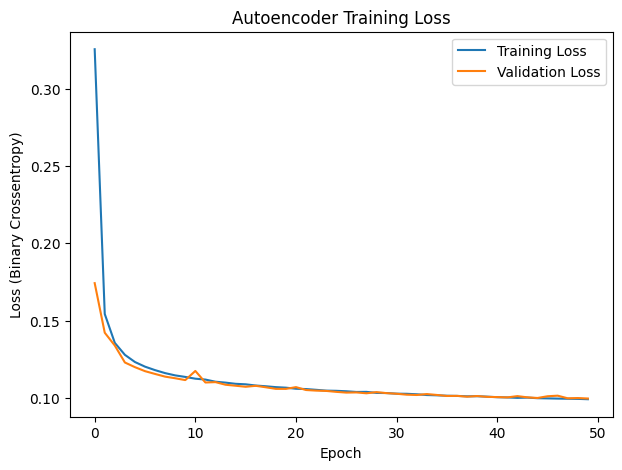

In [7]:
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (Binary Crossentropy)")
plt.legend()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


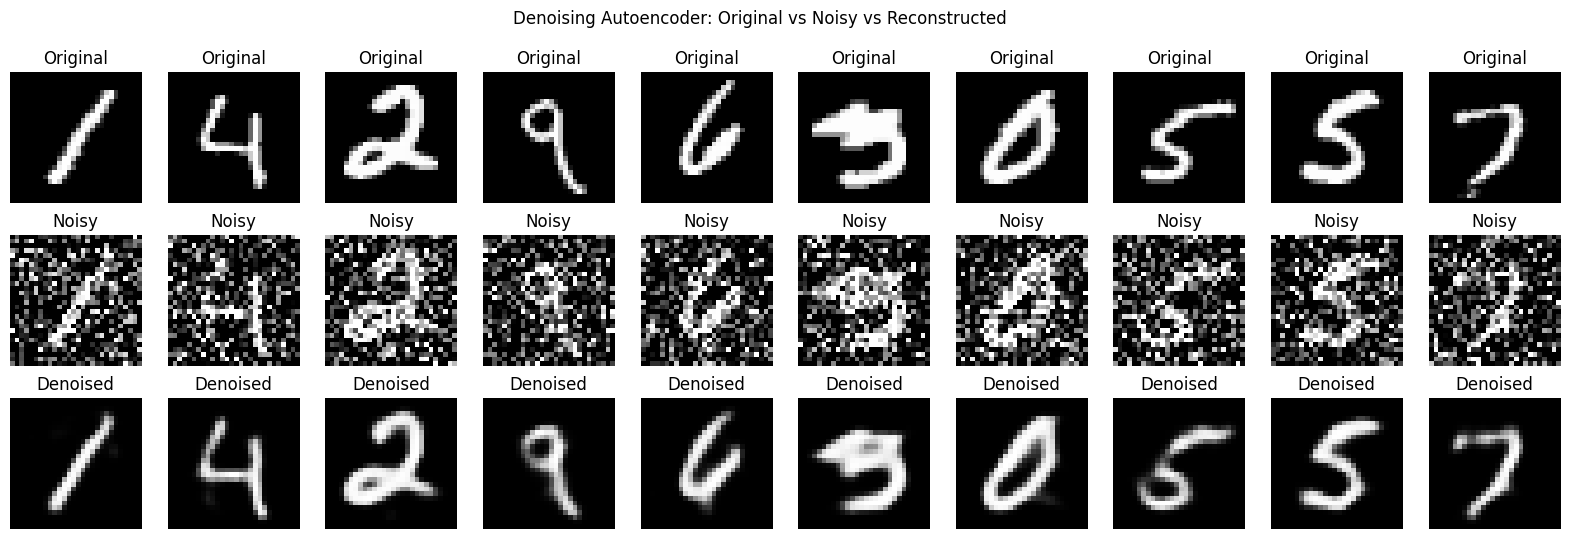

In [8]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):

    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.suptitle("Denoising Autoencoder: Original vs Noisy vs Reconstructed")
plt.show()

Mean Squared Error (Test Set): 0.012131


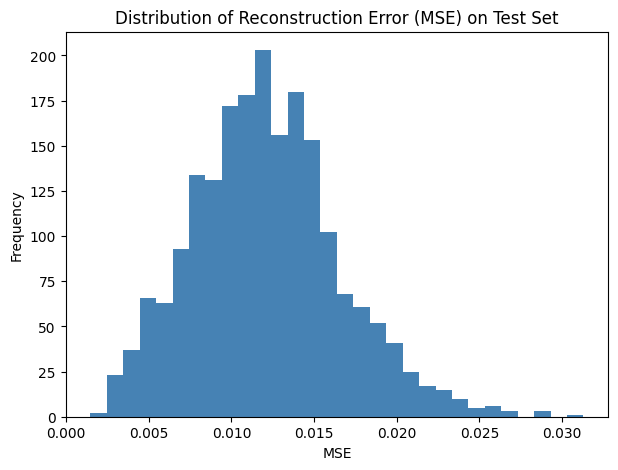

In [9]:
mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (Test Set): {mse:.6f}")

per_image_mse = np.mean(np.square(x_test - decoded_imgs), axis=(1, 2, 3))
plt.figure(figsize=(7, 5))
plt.hist(per_image_mse, bins=30, color="steelblue")
plt.title("Distribution of Reconstruction Error (MSE) on Test Set")
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.show()